In [1]:
!pip install arm_pyart matplotlib s3fs

In [87]:
import pandas as pd
import numpy as np
import geopy
from geopy import distance
from datetime import datetime, timezone

# Approximate locations of all NWS radar sites east of the Rockies
# I couldn't find a file so I had to manually collect the locations myself :3
radar_sites = pd.DataFrame(columns=['id', 'lat', 'lon'])
with open("RADAR_SITES.txt", 'r', encoding='utf-8') as file:
    for l in file:
        line = l.strip().split(sep=' ')
        radar_sites.loc[len(radar_sites)] = [line[0].upper(), float(line[1]), float(line[2])*-1]

# Find closest radar site given coordinates and the list of radars
def closest_radar(lat, lon, df=radar_sites):
  closest_id = ''
  min_dist = 9999999
  for i in range(len(df)):
    row = df.iloc[i]
    dist = distance.distance((row['lat'], row['lon']), (lat, lon)).km
    if dist < min_dist:
      closest_id = row['id']
      min_dist = dist
  return closest_id, min_dist

radar_sites

,id,lat,lon
0,KFTX,47.45,-111.38
1,KGGW,48.20,-106.62
2,KBLX,45.85,-108.61
3,KRIW,43.06,-108.48
4,KCYS,41.14,-104.80
...,...,...,...
109,KTYX,43.73,-75.66
110,KBOX,41.96,-71.14
111,KCXX,44.50,-73.14
112,KGYX,43.89,-70.24


##Pre-processing


In [ ]:
# HAIL REPORT PRE-PROCESSING
# Requires the SPC's csv file of hail reports 1955-2024 be uploaded to google colab.
# ------- This chunk should be skipped as it takes way too long to complete!!
# ------- Instead, download the hail_v2.csv file on the GitHub. That csv is what this chunk would output, no need to rerun.
hail_data = pd.read_csv('1955-2024_hail.csv')
print(f"{len(hail_data)} reports")
hail_data = hail_data[hail_data['yr'] >= 2010] #start with 2010
print(f"{len(hail_data)} reports")
hail_data = hail_data[hail_data['yr'] <= 2020] #end with 2020
print(f"{len(hail_data)} reports")
hail_data = hail_data[hail_data['mag'] > 0.99] #only include current severe standard
print(f"{len(hail_data)} reports")
hail_data = hail_data.drop(['elat', 'elon', 'len', 'wid', 'f1', 'f2', 'f3', 'f4', 'om', 'tz', 'st', 'stf', 'stn', 'inj', 'fat', 'loss', 'closs', 'ns', 'sn', 'sg'], axis=1)

# Add cols of closest radar and radar distance
radar = []
radar_dist = []
for i in range(len(hail_data)):
  row = hail_data.iloc[i]
  lat = row['slat']
  lon = row['slon']
  r, rd = closest_radar(lat, lon)
  radar.append(r)
  radar_dist.append(rd)
  if i % 2500 == 0:
    print(f"{i}/{len(hail_data)} processed ({(i/len(hail_data))*100:.2f}%)")
hail_data['radar'] = radar
hail_data['radar_dist'] = radar_dist

# Nothing too close to radar or too far away
hail_data = hail_data[(hail_data['radar_dist'] > 20) & (hail_data['radar_dist'] < 60)]
print(f"Final size: {len(hail_data)} reports")

# Add column with pandas datetime
hail_data['datetime'] = pd.to_datetime(
    hail_data['date'].astype(str) + ' ' + hail_data['time'].astype(str),
    format='%Y-%m-%d %H:%M:%S')

display(hail_data[:10])
hail_data.to_csv('hail_v2.csv', index=False)

##Downloading and plotting RADAR data

The next chunk only contains necessary functions to accomplish this. The `download_radar()` function was first created by and used with permission from Brandon Weart. We have made small edits to the function as necessary for the specific functionality of this project, but the original was his creation.

In [88]:
# Script for downloading NEXRAD radar files through the AWS Database with fsspec and S3
# Original author: Brandon Weart, Northern Illinois University
# Edits made by June Graff

"""
This script allows users to download NEXRAD radar files from the AWS Database using the fsspec library.
The user is prompted to enter the start date and time (yyyy-mm-dd HH:MM in UTC), end date and time, radar station code (E.G. KLOT), and the directory to save the radar files.
To run the script, you can either download this and change it to an .ipynb file by changing the extension...
Or you could run it in a terminal as a .py file by doing python /your/path/here/nexrad_download.py

"""

import fsspec
import os
from datetime import datetime, timedelta
import pyart
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import random

# Set up the S3 filesystem
fs = fsspec.filesystem("s3", anon=True)

# Download the earliest radar file <10 mins after report time
def download_radar(cutoff_dt, station, download_dir):
    fn = ''
    # Ensure the download directory exists
    os.makedirs(download_dir, exist_ok=True)

    # Generate the list of files for the specified date and hour range:
    date_str = cutoff_dt.strftime("%Y/%m/%d")
    date_str_compact = cutoff_dt.strftime("%Y%m%d")
    cutoff_hour = cutoff_dt.hour

    found = False
    for hour in range(cutoff_hour, cutoff_hour + 1):
        hour_str = f"{hour:02d}"
        all_files = fs.glob(
            f"s3://unidata-nexrad-level2/{date_str}/{station}/{station}{date_str_compact}_{hour_str}*"
        )

        filtered_files = sorted([f for f in all_files if not f.endswith("_MDM")])

        for file in filtered_files:
            basename = os.path.basename(file)
            time_part = basename.split("_")[1]
            file_dt = datetime.strptime(f"{date_str} {time_part}", "%Y/%m/%d %H%M%S").replace(tzinfo=timezone.utc)

            if file_dt >= cutoff_dt:
                local_filename = os.path.join(download_dir, 'data')
                try:
                    fn = basename
                    with fs.open(file, "rb") as f_in, open(local_filename, "wb") as f_out:
                        f_out.write(f_in.read())
                    # print(f"Downloaded {local_filename}")
                except Exception as e:
                    print(f"Failed to download {file}: {e}")
                found = True
                break
        if found:
          break
    # print(f"Download completed.")
    fn = 'data'
    return fn

# Returns a single radar image corresponding to the given hail report
# rpt should be a pandas Series; a row of the hail v2 dataframe
def get_radar(rpt):
  # Try to account for timezone issues
  ts1 = (pd.to_datetime(rpt['datetime']) + pd.Timedelta(minutes=60))
  ts1 = ts1.tz_localize('America/Chicago').tz_convert('UTC').to_pydatetime()
  # print(ts1)
  fn = download_radar(ts1, rpt['radar'], 'radar')
  return ts1, fn

# Plots reflectivity imagery associated with a hail report along with the location of the report itself
def plot_radar(rpt, filename, ts1):
  # Handle errors
  try:
    radar = pyart.io.read_nexrad_archive(f'radar/{filename}')
  except OSError as e:
        print(f"[Warning] Skipping file {filename}: {e}")
        return

  display = pyart.graph.RadarMapDisplay(radar)
  fig = plt.figure(figsize=(8, 8))
  ax = plt.axes(projection=ccrs.PlateCarree())

  rptlon = rpt['slon']
  rptlat = rpt['slat']
  ax.set_extent([rptlon-0.3, rptlon+0.3, rptlat-0.3, rptlat+0.3])

  # Plot reflectivity on map
  display.plot_ppi_map('reflectivity', sweep=0, ax=ax, projection=ccrs.PlateCarree(), lat_0=radar.latitude['data'][0], lon_0=radar.longitude['data'][0], cmap="ChaseSpectral")

  # Plot the location of the associated hail report
  ax.plot(rptlon, rptlat, marker='^', color='white', markersize=12, transform=ccrs.PlateCarree())
  ax.plot(rptlon, rptlat, marker='^', color='green', markersize=8, transform=ccrs.PlateCarree())
  ax.text(rptlon, rptlat, f'{rpt['mag']} in.', transform=ccrs.PlateCarree())

  # Plot the radar location (maybe not important)
  # radar = rpt['radar']
  # r = radar_sites[radar_sites['id']==radar]
  # ax.plot(r['lon'], r['lat'], marker='o', color='white', markersize=6, transform=ccrs.PlateCarree())
  # ax.plot(r['lon'], r['lat'], marker='o', color='black', markersize=3, transform=ccrs.PlateCarree())
  # ax.text(r['lon'], r['lat'], radar, transform=ccrs.PlateCarree())

  plt.title(f'{ts1} Reflectivity and hail report')
  plt.show()

##Manually verifying radar for hail reports

This is done to ensure the selected reports have associated RADAR data that is complete and captures at least close to the time the hail report was submitted. Hail reports whose associated radar scans were empty, incomplete (only covering a small area) or show no possibility of convection (all low reflectivity/background noise) were omitted.

~500 reports have been selected using this method and their indices in the `hail_v2` dataset have been preserved in the `good_indices` list, binned by hail size.

In [89]:
# UPDATE THIS AFTER EACH RUN TO SAVE WORK
def update_things():
  # Indices in hail_v2 that have been deemed worthy by her majesty
  good_indices = [[1231, 2532, 1473, 19292], [14878, 4325, 6039, 3090, 15122, 3162, 5757, 1464, 17392, 2206, 1255, 7902, 9960, 11400, 20080, 13537, 9495, 6486, 11766, 2355, 1731, 18513, 12816, 1560, 9269, 11770, 12273, 2693, 15059, 2982, 20152, 8348, 3075, 399, 14835, 3996, 6035, 9443, 20151, 3082, 9482, 1232, 16206, 10327, 5873, 2585, 8406, 10924, 8186, 6033, 9446, 1227, 9736, 16868, 19781, 2142, 1234, 418, 3077, 9733, 11052, 1236, 3163, 2928, 5765, 18983, 3079, 9194], [5259, 17406, 13153, 13217, 11568, 322, 11086, 13198, 15764, 14639, 12271, 4898, 3966, 16319, 19759, 5535, 1445, 7545, 17111, 3182, 9499, 9492, 6820, 16869, 11681, 18538, 9210, 13785, 10914, 6055, 16412, 18824, 18517, 930, 17390, 5258, 10063, 12497, 6061, 19489, 8369, 2353, 9679, 16613, 17846, 11335, 19227, 12275, 16925, 13570, 15935, 16782, 16558, 12274, 9489, 5242, 14437, 17401, 906, 2753, 3159, 5746, 4758, 731, 13530, 13042, 16371, 548, 18516, 14420, 19766, 19514, 13568, 19782, 19156, 19483, 19579, 19270, 11093, 2558, 19515, 13165, 15072, 17116, 15241, 15765, 2296, 13434, 4337, 19756, 12785, 19770, 17833, 9519, 10325, 16562, 3933, 13795, 15061, 17117, 6059, 16531, 15354, 11810, 3121, 18213, 15121, 18378, 7447, 17115, 10893, 5935, 620, 4385, 3015, 18514, 590, 2046, 20035, 19481, 10890, 12660, 8371, 6980, 1407, 12664, 2045, 6108, 5775, 16528, 5052, 16337, 14300, 17900, 2630, 7102, 9095, 12269, 16054, 18370, 1061, 13256, 3683, 6397, 5763, 5247, 19290, 11330, 19271, 19854, 2843, 9708, 10559, 11296, 5534, 17819, 9921, 3941], [5158, 16420, 14763, 17864, 8372, 10147, 6297, 16526, 12943, 18515, 5933, 846, 9123, 12944, 3059, 16425, 12277, 10901, 14024, 12250, 20138, 5311, 646, 16311, 14286, 1554, 658, 6395, 12299, 1334, 11125, 3054, 19260, 9477, 9953, 9932, 2619, 20132, 2695, 16399, 3576, 8350, 10381, 9857, 327, 8055, 13476, 10181, 10323, 12006, 19374, 14942, 4514, 6533, 15168, 14436, 6903, 1065, 16866, 14319, 19391, 12529, 8726, 325, 2044, 5156, 11628, 20166, 7459, 11851, 6063, 6546, 5304, 19765, 19844, 10755, 16654, 17295, 20058, 14591, 17903, 3532, 3055, 15087, 19262, 8453, 6597, 6302, 7481, 18379, 15014, 17889, 11126, 10485, 12199, 5037, 11447, 3430, 9839, 1173, 7761, 11816, 16554, 16598, 12662, 16076, 18790, 10643, 5269, 15162, 11136, 3258, 14943, 1446, 902, 16749, 13244, 11832, 19953, 7719, 1258, 3881, 20059, 1476, 19681, 19952, 11452, 2163, 931, 14296, 1799, 16456, 5907, 19962, 3580, 17172, 17714, 2551, 4176, 12517, 7223, 15808, 1026, 12590, 12891, 19194, 8800, 12485, 14529, 16899, 12115, 8537, 9682, 11111, 3458, 12659, 553, 15550], [15194, 1388, 6730, 12427, 484, 3476, 8473, 5703, 789, 10845, 12836, 9168, 10996, 19858, 16239, 4074, 7678, 14384, 7530, 16669, 18954, 14251, 18350, 535, 5619, 11495, 9291, 18960, 13440, 11047, 2660, 15046, 2935, 8563, 11144, 381, 2581, 1826, 2011, 13494, 17345, 6236, 16662, 4668, 225, 6158, 18340, 16779, 16209, 15972, 18345, 19117, 9543, 15161, 2902, 16923, 15165, 8866, 17845, 15464, 5127, 2529, 121, 14457, 12407, 16908, 7066, 15859, 3094, 11561, 8560, 17965, 9549, 18647, 4462, 13102, 18252, 13050, 16433, 16279, 9894, 9128, 10562, 10075, 13080, 10036, 10677, 19913, 18452, 489, 3616, 14428, 19812, 20185, 9644, 14231, 4392, 8393, 8901, 12990, 8640, 4053, 8995, 10379, 7614, 8165, 1633, 10631, 18010, 16600, 17942, 10067, 18316, 17663, 10366, 8418, 5887, 6721, 10010, 10328, 16135, 4627, 12247, 13338, 12319, 11950, 5921, 12108, 2146, 15024, 5938, 11757, 7527, 9286, 17148, 3125, 18293, 10049, 12296, 11079, 8252, 4196, 7295, 13635, 9688, 16549, 16595, 12489, 8041, 3319, 17200, 7241, 8385, 3582, 10347, 11185, 13814, 18022]]
  # Indices inside the CURRENT ix that have already been sorted through
  done = [15194, 1388, 6730, 12427, 484, 3476, 8473, 5703, 789, 10845, 12836, 16800, 9168, 10996, 19858, 16239, 4074, 7678, 14384, 7530, 16669, 18954, 14251, 18350, 15549, 535, 5619, 11495, 9291, 18960, 13440, 11047, 2660, 15046, 2935, 4665, 8563, 11144, 381, 2581, 1826, 2011, 13494, 17345, 6236, 6052, 16662, 4668, 225, 18492, 6158, 18340, 16779, 16209, 15972, 18345, 19117, 9543, 15161, 2902, 16923, 15165, 8866, 17845, 15464, 5127, 2529, 121, 14457, 12407, 16908, 10278, 7066, 15859, 3094, 11561, 8560, 17965, 9549, 18647, 4462, 13102, 1780, 18252, 13050, 16433, 16279, 9894, 15328, 9128, 10562, 10075, 13080, 10036, 10677, 19913, 18452, 489, 3616, 14428, 18680, 19812, 20185, 9644, 14231, 4392, 8393, 8901, 12990, 8640, 4053, 8995, 10379, 7614, 8165, 1633, 10631, 18010, 16600, 6956, 17942, 10067, 18316, 16759, 17663, 10366, 8418, 5887, 6721, 10010, 10328, 16135, 4627, 12247, 13338, 12319, 11950, 14162, 5921, 12108, 2146, 12743, 15024, 5938, 11590, 11757, 7527, 9286, 17148, 3125, 15739, 17248, 18293, 10049, 12296, 11079, 8252, 4196, 7295, 13635, 9688, 16549, 16595, 12489, 8041, 3319, 17200, 7241, 8385, 3582, 10347, 2748, 11185, 13814, 18022, 14615]
  return good_indices, done

In [ ]:
hail_data = pd.read_csv('hail_v2.csv')
import random
import time

# Saves indices of rpts with GOOD RADAR DATA by size bin
good_indices = [[],[],[],[],[]]
good_indices = update_things()[0]

# Conditions for each bin, 1-inch bins then 5+". This returns only the indices of the reports
i1 = np.where(hail_data['mag'] >= 5)[0].tolist()
i2 = np.where((hail_data['mag'] >= 4) & (hail_data['mag'] < 5))[0].tolist()
i3 = np.where((hail_data['mag'] >= 3) & (hail_data['mag'] < 4))[0].tolist()
i4 = np.where((hail_data['mag'] >= 2) & (hail_data['mag'] < 3))[0].tolist()
i5 = np.where(hail_data['mag'] < 2)[0].tolist()
ix = [i1, i2, i3, i4, i5]
ix_FINISHED = [0, 1]

# Making sure we get as many of the limited large hail reports as possible: start with 5+, then 4-5, then everything below.
for j in range(len(ix)):
  # Skip size bins that have already been completed, start at next one
  if(j in ix_FINISHED):
    print(f'skipping index {j}...')
  else:
    l = ix[j]
    done = []
    # If currently in progress, update list of already-sorted indices
    if j == len(ix_FINISHED):
      done = update_things()[1]
    line = ''
    while(line!='NEXT'):
      # if we have looped through everything in a category then go to next one
      unused = list(set(l) - set(done))
      if len(unused) == 0:
        break
      # pick index at random from stuff that hasn't already been done
      idx = unused[random.randint(0, len(unused)-1)]
      rpt = hail_data.iloc[idx]

      # DISPLAY
      ts1, filename = get_radar(rpt)
      plot_radar(rpt, filename, ts1)
      # let colab render first so it doesn't override the input box
      time.sleep(0.1)

      # let June evaluate
      line = input()
      done.append(idx)
      if line == 'y':
        good_indices[j].append(idx)
      # print
      print(f"\n#{j} EVALUATED:\n{len(done)}/{len(l)}\nINDEX: {idx}\nINDICES SAVED: {len(good_indices[0])};{len(good_indices[1])};{len(good_indices[2])};{len(good_indices[3])};{len(good_indices[4])}")
      # if the next input is NEXT, it switches to the next hail size bin.
print(good_indices)

##Developing features for our model


We want to mask our data only to the area where DBZ ≥ 30 because that is a threshold often used to demarcate convection. This should also help to reduce noisy background signals. After that, inside that specific area, we want to calculate:
- Area over which DBZ ≥ 30, ≥ 50, ≥ 60
- Max, mean DBZ
- Mean, mean, min ZDR
- Mean, min CC

We iterate through the hail reports (only the previously-verified indices) and, for each one: download radar -> mask to the area 0.3 degrees lat/lon in any direction from report -> calculate the variables -> add them to the hail csv.

Once this step is done we are free to begin developing our ML model.

In [ ]:
# This chunk and the next were used to produce the FINAL dataset (hail_v3.csv), which is included in the GitHub.
# Due to issues with Google Colab, the data had to be processed in six parts and combined later.

import time
import gc
c=0
e=0
s=4
cr=s
hail_data = pd.read_csv('hail_v2.csv')
hail_data_3 = pd.DataFrame()

# Save in separate parts because colab keeps crashing
for row in update_things()[0][s:s+1]:
  cr = cr+1
  e=0
  c=0
  for i in row:
    if e+c > 79:
      # Get fields of radar data
      rpt = hail_data.iloc[i]
      ts1, filename = get_radar(rpt)
      radar = pyart.io.read_nexrad_archive("radar/data")
      sweep = radar.get_slice(0)

      # It's all in a big try/catch because I don't know how else to account for this, some files do not have zdr/cc and cannot be used
      try:
        dbz = radar.fields['reflectivity']['data'][sweep]
        zdr = radar.fields['differential_reflectivity']['data'][sweep]
        cc = radar.fields['cross_correlation_ratio']['data'][sweep]
        # To help with memory usage
        dbz = dbz.astype('float32')
        zdr = zdr.astype('float32')
        cc = cc.astype('float32')

        # Filter by lat and lon and minimum dbz
        gate_lat, gate_lon, gate_alt = radar.get_gate_lat_lon_alt(0)
        rptlon = rpt['slon']
        rptlat = rpt['slat']
        b = [rptlon-0.3, rptlon+0.3, rptlat-0.3, rptlat+0.3]
        dbz_filter = dbz[(gate_lon >= b[0]) & (gate_lon <= b[1]) & (gate_lat >= b[2]) & (gate_lat <= b[3]) & (dbz >= 30)]
        zdr_filter = zdr[(gate_lon >= b[0]) & (gate_lon <= b[1]) & (gate_lat >= b[2]) & (gate_lat <= b[3]) & (dbz >= 30)]
        # Filtering out unrealistic values because ew
        zdr_filter = zdr_filter[(zdr_filter > -2) & (zdr_filter < 5)]
        cc_filter = cc[(gate_lon >= b[0]) & (gate_lon <= b[1]) & (gate_lat >= b[2]) & (gate_lat <= b[3]) & (dbz >= 30)]

        print(f'\n--- Bin {cr}/5: report {c}/{len(row)}')
        # max/mean dbz
        max_dbz = dbz_filter.max()
        mean_dbz = round(dbz_filter.mean(), 1)
        rpt['max_dbz'] = max_dbz
        rpt['mean_dbz'] = mean_dbz

        # max/mean/min zdr
        max_zdr = zdr_filter.max()
        mean_zdr = round(zdr_filter.mean(), 1)
        min_zdr = zdr_filter.min()
        rpt['max_zdr'] = max_zdr
        rpt['mean_zdr'] = mean_zdr
        rpt['min_zdr'] = min_zdr

        # mean/min cc
        mean_cc = round(cc_filter.mean(), 2)
        min_cc = cc_filter.min()
        rpt['mean_cc'] = mean_cc
        rpt['min_cc'] = min_cc

        # number of 30/50dbz+ pixels.
        # not as reliable as actually finding the area but that feels too sophisticated for me right now
        count_30dbz = dbz_filter.size
        count_50dbz = dbz_filter[dbz_filter >= 50].size
        count_60dbz = dbz_filter[dbz_filter >= 60].size
        rpt['count_30dbz'] = count_30dbz
        rpt['count_50dbz'] = count_50dbz
        rpt['count_60dbz'] = count_60dbz

        # Add to the dataframe with new columns included
        print('dbz: ', max_dbz, mean_dbz, '\nzdr: ', max_zdr, mean_zdr, min_zdr, '\ncc: ', mean_cc, min_cc, '\n', count_30dbz, count_50dbz, count_60dbz)
        hail_data_3 = pd.concat([hail_data_3, pd.DataFrame([rpt])], ignore_index = True)

        # Helps with memory usage please stop crashing
        del radar, dbz, zdr, cc, gate_lat, gate_lon
        gc.collect()
      except KeyError:
        e=e+1
        print(f'\n--- Missing ZDR/CC, skipping this file ({e} errors of {c} total)')
    c=c+1
hail_data_3.to_csv('hail_v3_p6.csv')
hail_data_3

In [17]:
# Combine the separate files into one final dataset including ML variables
d = []
for i in range(1,7):
  df = pd.read_csv(f'hail_v3_p{i}.csv')
  d.append(df)
hail_data_3 = pd.concat(d, ignore_index=True)

hail_data_3.to_csv('hail_v3.csv')

##Preparing to train


In [148]:
# Coming back to make a few more derived variables because the first iteration of the model was Not Good
hail_data = pd.read_csv('hail_v3.csv')
display(hail_data[:5])

hail_data['ratio_50_30'] = hail_data['count_50dbz'] / (hail_data['count_30dbz'] + 1)
hail_data['ratio_60_50'] = hail_data['count_60dbz'] / (hail_data['count_50dbz'] + 1)
hail_data['zdr_range'] = hail_data['max_zdr'] - hail_data['min_zdr']
hail_data = hail_data.drop(['Unnamed: 0.1', 'Unnamed: 0', 'mag_binned'], axis=1)

# One final bit of processing, create column of sig vs. not sig hail
sig = []
for i, row in hail_data.iterrows():
  sig.append(int(row['mag'] >= 2.0))
hail_data['sig'] = sig

display(hail_data[:5])

hail_data.to_csv('hail_v4.csv')

,Unnamed: 0.1,Unnamed: 0,yr,mo,dy,date,time,mag,slat,slon,...,mean_dbz,max_zdr,mean_zdr,min_zdr,mean_cc,min_cc,count_30dbz,count_50dbz,count_60dbz,mag_binned
0,0,0,2020,5,22,2020-05-22,17:40:00,5.33,34.0800,-98.560,...,41.9,4.9375,2.0,-1.9375,0.97,0.208333,17858,2646,40,5
1,1,1,2017,5,27,2017-05-27,20:07:00,4.00,34.9900,-97.450,...,40.8,4.9375,2.0,-1.9375,0.97,0.208333,12891,960,3,4
2,2,2,2012,6,12,2012-06-12,21:15:00,4.50,34.1595,-103.355,...,42.3,4.9375,2.2,-1.9375,0.96,0.215000,2935,733,152,4
3,3,3,2017,6,15,2017-06-15,18:15:00,4.00,37.0500,-98.480,...,43.0,4.9375,2.0,-1.9375,0.94,0.208333,10853,2245,89,4
4,4,4,2019,5,23,2019-05-23,17:43:00,4.25,38.4200,-81.470,...,45.4,4.9375,2.3,-1.9375,0.95,0.208333,3470,1161,121,4


,yr,mo,dy,date,time,mag,slat,slon,radar,radar_dist,...,min_zdr,mean_cc,min_cc,count_30dbz,count_50dbz,count_60dbz,ratio_50_30,ratio_60_50,zdr_range,sig
0,2020,5,22,2020-05-22,17:40:00,5.33,34.0800,-98.560,KFDR,47.494218,...,-1.9375,0.97,0.208333,17858,2646,40,0.148161,0.015111,6.875,1
1,2017,5,27,2017-05-27,20:07:00,4.00,34.9900,-97.450,KTLX,40.498047,...,-1.9375,0.97,0.208333,12891,960,3,0.074465,0.003122,6.875,1
2,2012,6,12,2012-06-12,21:15:00,4.50,34.1595,-103.355,KFDX,56.598081,...,-1.9375,0.96,0.215000,2935,733,152,0.249659,0.207084,6.875,1
3,2017,6,15,2017-06-15,18:15:00,4.00,37.0500,-98.480,KVNX,47.044388,...,-1.9375,0.94,0.208333,10853,2245,89,0.206836,0.039626,6.875,1
4,2019,5,23,2019-05-23,17:43:00,4.25,38.4200,-81.470,KRLX,25.590417,...,-1.9375,0.95,0.208333,3470,1161,121,0.334486,0.104131,6.875,1


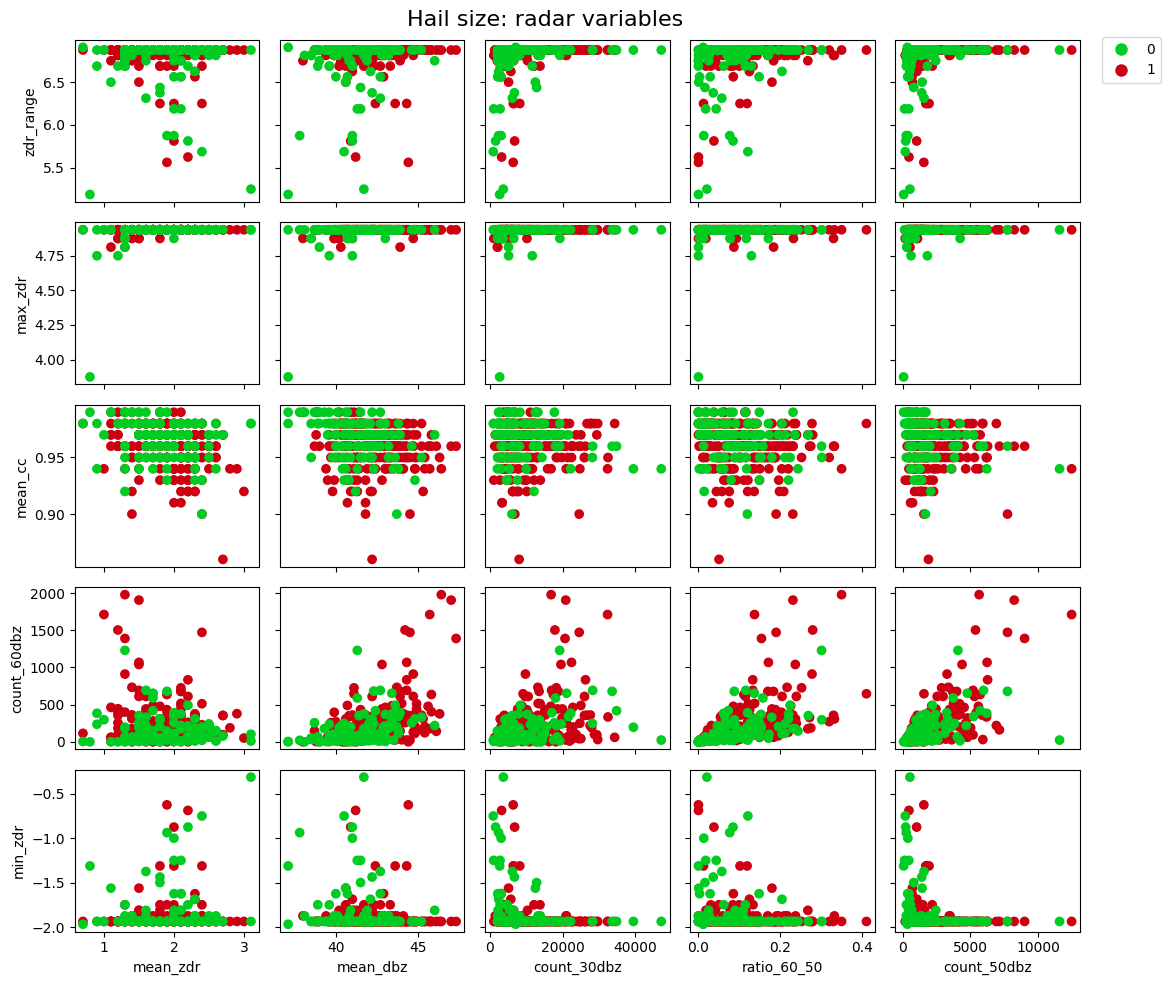

In [149]:
# This code is largely reused from part of what I wrote for exam 1
# I just want to see the relationships between different features to make sure the model can distinguish things
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import random

hail_data = pd.read_csv('hail_v4.csv')

# Define rows and columns of our display, each row/col is one variable to be examined with others
# I am shuffling the list and running the code repeatedly to examine more combinations
feature_list = ['max_dbz',
       'mean_dbz', 'max_zdr', 'mean_zdr', 'min_zdr', 'mean_cc', 'min_cc',
       'count_30dbz', 'count_50dbz', 'count_60dbz', 'ratio_50_30', 'ratio_60_50', 'zdr_range']
random.shuffle(feature_list)
rows = feature_list[:5]
cols = feature_list[5:10]

# Create new column of colors corresponding to the labeled storm morphology
colors = []
# Dictionary to make life easier
map = {0:'#0c2', 1:'#c01'}
for m in hail_data['sig']:
  colors.append(map[m])
hail_data['colors'] = colors

# Create the subplots
fig, axes = plt.subplots(5, 5, figsize=(11,10))
for i_row in range(5):
  for i_col in range(5):
    a = axes[i_row, i_col]
    # Fill in each plot, coloring points based on their labeled morphology
    a.scatter(hail_data[cols[i_col]], hail_data[rows[i_row]], color=hail_data['colors'])
    # Label axes only on the outside of the figure
    a.set_xlabel(cols[i_col])
    a.set_ylabel(rows[i_row])
    a.label_outer()

# Creating legend for the colors
elements = []
for l in map.keys():
  c = map[l]
  # I used the bottom example on MatPlotLib docs for help with this solution
  # https://matplotlib.org/stable/gallery/text_labels_and_annotations/custom_legends.html
  elements.append(Line2D([0], [0], marker='o', color='#fff', markerfacecolor=c, label=l, markersize=10))

fig.legend(handles=elements, loc='upper left', bbox_to_anchor=(1,0.96))
fig.suptitle('Hail size: radar variables', fontsize=16)
plt.tight_layout()
plt.show()

# When done plotting, remove the colors column to avoid messing with future dataframe operations
hail_data = hail_data.drop('colors', axis=1)

In [164]:
# Split the dataset into training and testing data.
display(hail_data['yr'].value_counts())
hail_data = pd.read_csv('hail_v4.csv')
hail_data = hail_data.drop(['Unnamed: 0', 'mo', 'dy', 'slat', 'slon', 'radar_dist', 'date', 'time', 'radar', 'datetime'], axis=1)

# Separating these temporally, the testing data will be the final year (2020) and everything else will be used for training.
# Inside the training data, we can use 2019 for validation, like an initial test with which we can adjust the model.
hail_train = hail_data[hail_data['yr'] <= 2016]
hail_val = hail_data[(hail_data['yr'] == 2017) | (hail_data['yr'] == 2018)]
hail_test = hail_data[(hail_data['yr'] == 2019) | (hail_data['yr'] == 2020)]
print(f'\nSample counts:\nTraining: {len(hail_train)}\t Validation: {len(hail_val)}\t Testing: {len(hail_test)}')

# Comparing the validation/testing data to the training dataset:
print('\n\n--- TRAINING:')
display(hail_train.drop(['yr'], axis=1).describe().drop(['count', '25%', '50%', '75%'], axis=0))
print('\n\n--- VALIDATION:')
display(hail_val.drop(['yr'], axis=1).describe().drop(['count', '25%', '50%', '75%'], axis=0))
print('\n\n--- TESTING:')
display(hail_test.drop(['yr'], axis=1).describe().drop(['count', '25%', '50%', '75%'], axis=0))

,count
yr,
2016,54
2014,50
2015,49
2019,46
2020,45
2018,43
2017,40
2013,33
2012,21



Sample counts:
Training: 209	 Validation: 83	 Testing: 91


--- TRAINING:


,mag,max_dbz,mean_dbz,max_zdr,mean_zdr,min_zdr,mean_cc,min_cc,count_30dbz,count_50dbz,count_60dbz,ratio_50_30,ratio_60_50,zdr_range,sig
mean,2.397990,67.370813,42.069856,4.928230,1.890431,-1.877691,0.965359,0.257871,10048.985646,2036.277512,213.760766,0.196957,0.103901,6.805921,0.665072
std,1.041801,3.465151,1.789687,0.075609,0.404665,0.180904,0.015535,0.126015,7481.815467,1917.898800,297.977042,0.070889,0.075310,0.209438,0.473099
min,1.000000,55.000000,37.100000,3.875000,0.800000,-1.937500,0.900000,0.208333,985.000000,67.000000,0.000000,0.024479,0.000000,5.187500,0.000000
max,4.750000,75.500000,47.300000,4.937500,2.700000,-0.625000,0.990000,0.885000,47079.000000,12473.000000,1979.000000,0.435525,0.350576,6.875000,1.000000




--- VALIDATION:


,mag,max_dbz,mean_dbz,max_zdr,mean_zdr,min_zdr,mean_cc,min_cc,count_30dbz,count_50dbz,count_60dbz,ratio_50_30,ratio_60_50,zdr_range,sig
mean,2.301325,67.722892,41.804819,4.935994,1.926506,-1.891566,0.958675,0.241667,10474.638554,1850.795181,170.445783,0.182351,0.099722,6.827560,0.710843
std,0.920524,3.959592,1.541768,0.009643,0.441473,0.223880,0.020823,0.101878,7506.921820,1450.148451,174.747431,0.065747,0.083626,0.223775,0.456127
min,1.000000,59.000000,38.500000,4.875000,0.700000,-1.937500,0.900000,0.208333,1093.000000,137.000000,0.000000,0.024334,0.000000,5.250000,0.000000
max,4.250000,78.500000,45.200000,4.937500,3.100000,-0.312500,0.990000,0.808333,39437.000000,7143.000000,733.000000,0.319903,0.411465,6.875000,1.000000




--- TESTING:


,mag,max_dbz,mean_dbz,max_zdr,mean_zdr,min_zdr,mean_cc,min_cc,count_30dbz,count_50dbz,count_60dbz,ratio_50_30,ratio_60_50,zdr_range,sig
mean,2.465824,68.307692,41.880220,4.932005,1.947253,-1.880151,0.962967,0.233095,11319.318681,2049.043956,194.813187,0.185109,0.092016,6.812157,0.725275
std,0.984481,4.024073,1.722738,0.028940,0.388256,0.208087,0.019916,0.079256,6974.373686,1512.769975,235.785209,0.070277,0.068666,0.212075,0.448849
min,1.000000,58.000000,37.100000,4.750000,0.700000,-1.968750,0.860000,0.208333,1383.000000,273.000000,0.000000,0.048315,0.000000,5.625000,0.000000
max,5.330000,77.500000,46.100000,4.937500,3.000000,-0.687500,0.990000,0.661667,29645.000000,7738.000000,1472.000000,0.414328,0.275148,6.906250,1.000000


Comparing the training dataset with the testing and validation, we see a similar mean `mag` (hail size) in all three, hovering around 2.2-2.6, with a standard deviation of about 1. Also, looking briefly at the variables, the means are generally similar between the different datasets, with the real exceptions being the 30dbz and 50dbz counts which appear to generally be larger in the 2020 (testing) dataset. Our three datasets are completely separate from one another and appear to be representative of the population.

##Training our model

In [165]:
# These are the columns the model can use in prediction
cols = hail_data.drop(['mag', 'yr', 'sig'],axis=1).columns.to_list()
# print(cols)

x_train = hail_train[cols].to_numpy()
y_train = hail_train['sig'].to_numpy()

x_val = hail_val[cols].to_numpy()
y_val = hail_val['sig'].to_numpy()

x_test = hail_test[cols].to_numpy()
y_test = hail_test['sig'].to_numpy()

# Create random forest classifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
forest = RandomForestClassifier(max_depth=2, random_state=0).fit(X=x_train, y=y_train)

# Evaluate predictions from default state
predictions = forest.predict(x_test)

sklearn_acc = accuracy_score(y_test, predictions)
sklearn_pre = precision_score(y_test, predictions, average='weighted')
sklearn_rec = recall_score(y_test, predictions, average='weighted')
sklearn_f1 = f1_score(y_test, predictions, average='weighted')

print(f"Accuracy {sklearn_acc:.2f}\tPrecision {sklearn_pre:.2f}\tRecall {sklearn_rec:.2f}\nF1 {sklearn_f1:.2f}")

Accuracy 0.73	Precision 0.68	Recall 0.73
F1 0.68


In [166]:
from sklearn.ensemble import RandomForestClassifier

# Further fine-tuning to find the best random forest we can
# Values to test
depths = [3, 5, 7, 10]
n_estimators = [50, 100, 200]
minleaves = [1, 2, 5]
max_features_opts = ['sqrt', 'log2']

model_test = pd.DataFrame(columns=['f1_score', 'accuracy', 'precision', 'recall', 'max_depth', 'n_estimators', 'min_samples_leaf', 'max_features'])
# Loop through all combinations of these parameters
for depth in depths:
  for n_est in n_estimators:
    for minleaf in minleaves:
      for max in max_features_opts:
          # Create a random forest
          rf = RandomForestClassifier(n_estimators=n_est, max_depth=depth, min_samples_leaf=minleaf, max_features=max, class_weight='balanced', random_state=0).fit(x_train, y_train)

          # Predict and evaluate
          prediction = rf.predict(x_val)
          f1 = f1_score(y_val, prediction, average='weighted')
          ac = accuracy_score(y_val, prediction)
          pr = precision_score(y_val, prediction, average='weighted', zero_division=np.nan)
          re = recall_score(y_val, prediction, average='weighted')
          model_test.loc[len(model_test)] = [f1, ac, pr, re, depth, n_est, minleaf, max]

# Print out the top values by f-score
model_test = model_test.sort_values(by='f1_score', ascending=False)
display(model_test.iloc[:5])

,f1_score,accuracy,precision,recall,max_depth,n_estimators,min_samples_leaf,max_features
67,0.710417,0.734940,0.711242,0.734940,10,200,1,log2
66,0.710417,0.734940,0.711242,0.734940,10,200,1,sqrt
3,0.702440,0.710843,0.697456,0.710843,3,50,2,log2
2,0.702440,0.710843,0.697456,0.710843,3,50,2,sqrt
9,0.702440,0.710843,0.697456,0.710843,3,100,2,log2


##Evaluating the model

In [181]:
from sklearn.metrics import confusion_matrix
# Picking the best-performing model
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=1, max_features='log2', class_weight='balanced', random_state=0).fit(x_train, y_train)
# Final test run!
prediction = rf.predict(x_test)

ac = accuracy_score(y_test, prediction)
pr = precision_score(y_test, prediction, average='weighted', zero_division=np.nan)
re = recall_score(y_test, prediction, average='weighted')
f1 = f1_score(y_test, prediction, average='weighted')

# Make a better plot of this later
print(f"Accuracy {ac:.2f}\tPrecision {pr:.2f}\tRecall {re:.2f}\nF1 {f1:.2f}\n\nConfusion Matrix:")
print(confusion_matrix(y_test, prediction))

Accuracy 0.73	Precision 0.69	Recall 0.73
F1 0.70

Confusion Matrix:
[[ 7 18]
 [ 7 59]]


The final random forest model has an F1-score of 0.70, which is by no means ideal. Still, it is a large improvement over the earliest iterations, which saw F1-scores closer to 0.45.